<a href="https://colab.research.google.com/github/sbasu777/drsanjaybasu/blob/main/Module_3_Quantum_Course_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit[visualization];
!pip install qutip
!pip install qiskit_aer;

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=f2944e6a61e598a5caacfb691602c661e7f83668f4d59683cdd05804a1f21a11
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import numpy as np
import pylab as plt
import qiskit
import qutip
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [4]:
def RunMe(circuit,a=None):
  numQubits=circuit.num_qubits
  if a!=None:
    numQubits=max(numQubits,a.num_qubits)
    initCircuit=QuantumCircuit(a.num_qubits,a.num_qubits)
    initCircuit.initialize(a)
    circuit=AddCircuits([initCircuit,circuit])
  circuit.save_statevector(label='myStateVector')
  compiled_circuit = transpile(circuit, simulator)
  resultA = simulator.run(compiled_circuit).result()
  forward=list(range(0,numQubits))
  reverse=forward[::-1]
  circuit.measure(forward,reverse)
  compiled_circuit = transpile(circuit, simulator)
  resultB = simulator.run(compiled_circuit).result()
  return resultA.data()['myStateVector'],resultB.data()['counts']


def MakeState(v):
  numWires=int(round(np.log2(len(np.array(v)))))
  qc1=QuantumCircuit(numWires,numWires)
  qc1.initialize(v)
  a,_=RunMe(qc1)
  return a

def PrintDirac(out_state_a):
  out_state=np.asarray(out_state_a)
  l=len(out_state)
  num_qubits=int(round(np.log(len(out_state))/np.log(2)))
  for i in range(0,l):
    if not np.isclose(out_state[i],0):
      print(str(out_state[i])+'|'+bin(i)[2:].zfill(num_qubits)[::-1]+'>',end=' + ')
  print()

def PlotBloch(v,bb):
  vv=np.asarray(v)
  a=vv[0]*np.conj(vv[0])
  b=vv[1]*np.conj(vv[0])
  x = np.real(2.0 * b.real)
  y = np.real(2.0 * b.imag)
  z = np.real(2.0 * a - 1.0)
  bb.add_vectors([x,y,z])
  return

def PlotState(v,plotAll=True,myTitle=""):
  plt.figure(figsize=(10, 6))
  if plotAll:
    N=len(np.asarray(v))
  else:
    N=len(np.asarray(v))//2
  vv=np.zeros(N,dtype=complex)
  vv[:]=np.asarray(v)[0:N]
  vv=vv*np.exp(-1.j*np.angle(vv[0]))
  plt.axhline(0)
  idx=0
  plt.plot([int(idx),int(idx)],[0,np.real(vv[0])],color='red',label='real')
  plt.plot([idx+0.1,idx+0.1],[0,np.imag(vv[0])],color='blue',label='imaginary')
  for idx,i in enumerate(vv):
    plt.plot([int(idx),int(idx)],[0,np.real(i)],color='red')
    plt.plot([int(idx)],[np.real(i)],'o',color='red')
  for idx,i in enumerate(vv):
    plt.plot([idx+0.1,idx+0.1],[0,np.imag(i)],color='blue')
    plt.plot([idx+0.1],[np.imag(i)],'o',color='blue')
  avg=np.average(vv)
  plt.axhline(np.real(avg),linestyle='--')
  plt.ylim(-1,1)
  plt.title(myTitle)
  ### turn all the tic marks on the pylab plot to binary numbers
  xs=list(range(0,N))
  toFill=np.log2(N).astype(int)
  # plt.xticks(xs,[bin(x)[2:].zfill(toFill) for x in xs])
  plt.legend()
  plt.show()



def AddCircuits(theCircuits):
  numQubits=np.array([c.num_qubits for c in theCircuits])
  numQubits=np.max(numQubits)
  circuit=QuantumCircuit(numQubits,numQubits)
  for i in range(0,len(theCircuits)):
    circuit=circuit.compose(theCircuits[i],qubits=list(range(0,theCircuits[i].num_qubits)))
  return circuit


def Mark(r,N):
  circuit=QuantumCircuit(N,N)
  circuit.barrier()


  myString=np.binary_repr(r,width=N)[::-1]
  for i in range(0,len(myString)):
    if myString[i]=='0':
      circuit.x(i)
  circuit.barrier()

  circuit.h(N-1)
  circuit.mcx(list(range(0,N-1)), N-1,mode='noancilla')
  circuit.h(N-1)
  circuit.barrier()

  for i in range(0,len(myString)):
    if myString[i]=='0':
      circuit.x(i)
  circuit.barrier()
  return circuit

def InitializeCircuitRandom(N):
  r=np.random.random(2**N)
  r=r/np.linalg.norm(r)
  circuit=QuantumCircuit(N,N)
  circuit.initialize(list(r))
  return circuit


def InitializeCircuit(my_string,N):
  circuit = QuantumCircuit(N,N)
  circuit.initialize(my_string[::-1])
  return circuit

simulator = AerSimulator()

## Question 1: EPR Pairs
Anticipated time: 20 minutes

In the live session, you write a function `def MakeEPR()`
for making the four EPR pairs from each of the four two qubit computational basis states.  

It will be critical for networking protocols (such as teleportation) that we are able to both
* unmake and EPR pair as well as
* take an EPR pair and convert it to any other EPR pair by just doing gates on one input.

In this problem, you will write functions which generate circuits to do both of these operations.  
you are going to expand upon this and build circuits which disentangle EPR pairs `def UnmakeEPR()` as well as a circuit `def ChangeEPR(i,j)` where `i` and `j` specify that you want to move from EPR pair i to EPR pair j.



### a. Unmaking EPR Pairs

Write the function `UnmakeEPR()` which takes an EPR pair as input and converts it back to a product state.  One way to think about making this circuit is that you want to run the `MakeEPR()` pair circuit backwards. This can be done by reversing the order of the gates and replacing each gate with its inverse (in this case the inverse of the relevant gates is the gate itself).   You can find the correct circuit in the quantum subroutine video.  


Test this function by first making an EPR pair and then unmaking it, verifying that you get back where you started.  In other words:
```
inputValues='01' # <-- this is where you start
circuit=AddCircuits([InitializeCircuit(inputValues,2),MakeEPR()])
epr_pair,measure=RunMe(circuit)
print("This should be the EPR pair")
PlotState(epr_pair)
circuit=UnmakeEPR()
display(circuit.draw(output="mpl"))
output,measure=RunMe(circuit,epr_pair)
print("Now we should be back to our initial product state")
PlotState(output)
PrintDirac(output)
```
should return a circuit which is `1.0 |01>`

Verify that you get back your input for all four initialization of the qubits.  

*Note:* Your UnmakeEPR() requires a two qubit gate.  This might be somewhat surprising since building EPR pairs generates entanglement but it doesn't actual increase entanglement to unmake an EPR pair.  


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

This should be the EPR pair:


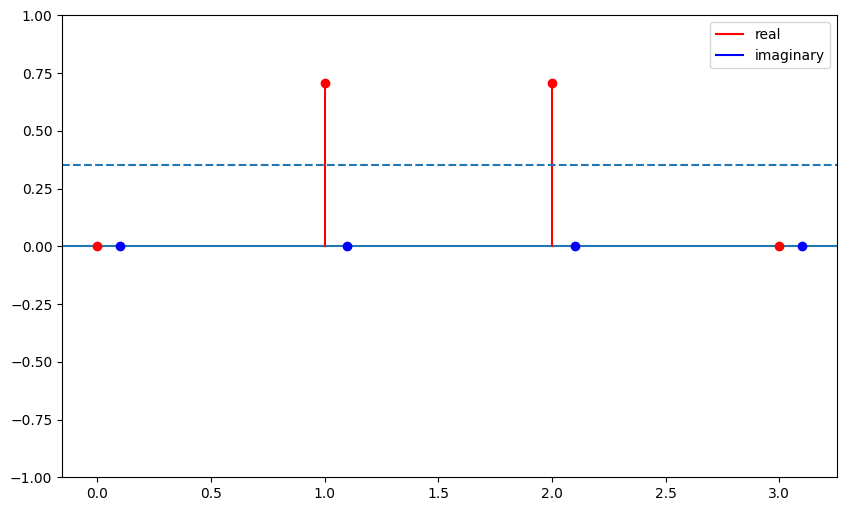


Now we should be back to our initial product state:


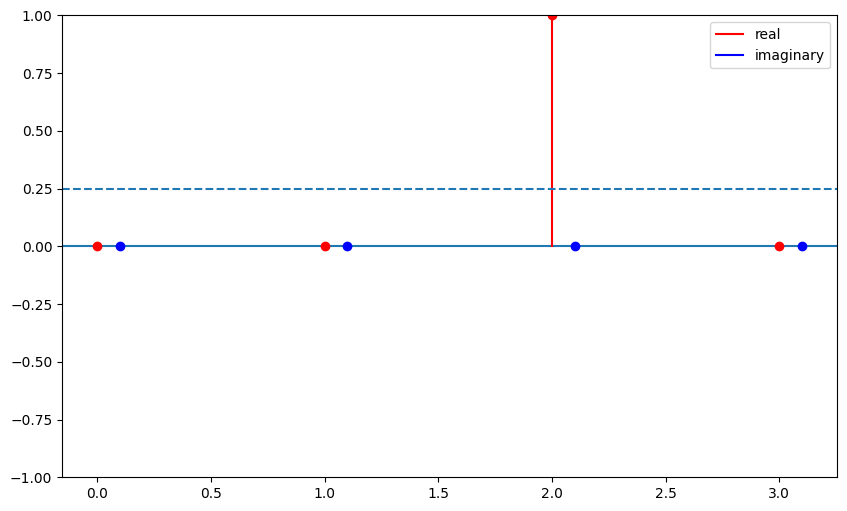

(1-6.123233995736765e-17j)|01> + 


In [6]:
### ANSWER HERE
def MakeEPR():
    # Create a circuit with 2 qubits
    circuit = QuantumCircuit(2, 2)

    # Apply Hadamard gate on first qubit
    circuit.h(0)

    # Apply CNOT gate
    circuit.cx(0, 1)

    return circuit

### ANSWER HERE
def UnmakeEPR():
    # Create a circuit with 2 qubits
    circuit = QuantumCircuit(2, 2)

    # Apply CNOT gate (reverse of the last operation in EPR creation)
    circuit.cx(0, 1)

    # Apply Hadamard gate on first qubit (reverse of first operation)
    circuit.h(0)

    return circuit

# Test the UnmakeEPR function
inputValues = '01'  # Starting with |01⟩ state
circuit = AddCircuits([InitializeCircuit(inputValues, 2), MakeEPR()])
epr_pair, measure = RunMe(circuit)
print("This should be the EPR pair:")
PlotState(epr_pair)

# Now unmake the EPR pair
unmake_circuit = UnmakeEPR()
output, measure = RunMe(unmake_circuit, epr_pair)
print("\nNow we should be back to our initial product state:")
PlotState(output)
PrintDirac(output)

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>


### b.  Entanglement and UnmakeEPR()

Run your `UnmakeEPR()` on the four orthogonal product states $|00\rangle, |01\rangle, |10\rangle, |11\rangle$.  Do any of them generate entanglement?  Come up with an unentangled state which becomes entangled under the application of this circuit?



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [9]:
### ANSWER HERE

def RunMe(circuit,a=None):
  numQubits=circuit.num_qubits
  # Changed line: check if 'a' is not None and is not a NumPy ndarray
  if a is not None and not isinstance(a, np.ndarray):
    numQubits=max(numQubits,a.num_qubits)
    initCircuit=QuantumCircuit(a.num_qubits,a.num_qubits)
    initCircuit.initialize(a)
    circuit=AddCircuits([initCircuit,circuit])
  circuit.save_statevector(label='myStateVector')
  compiled_circuit = transpile(circuit, simulator)
  resultA = simulator.run(compiled_circuit).result()
  forward=list(range(0,numQubits))
  reverse=forward[::-1]
  circuit.measure(forward,reverse)
  compiled_circuit = transpile(circuit, simulator)
  resultB = simulator.run(compiled_circuit).result()
  return resultA.data()['myStateVector'],resultB.data()['counts']

# Test UnmakeEPR on all computational basis states
basis_states = ['00', '01', '10', '11']

for state in basis_states:
    print(f"\nTesting with initial state |{state}⟩:")

    # Create initial state and make EPR pair
    circuit = AddCircuits([InitializeCircuit(state, 2), MakeEPR()])
    epr_state, _ = RunMe(circuit)

    print("EPR state:")
    PrintDirac(epr_state)

    # Now unmake the EPR pair
    unmake_circuit = UnmakeEPR()
    final_state, _ = RunMe(unmake_circuit, epr_state)

    print("Final state after unmaking:")
    PrintDirac(final_state)

# Test with a superposition state that will become entangled
# Initialize in superposition (|0⟩ + |1⟩)/√2 for first qubit
superposition_state = np.array([1, 1, 0, 0]) / np.sqrt(2)
circuit = QuantumCircuit(2, 2)
circuit.initialize(superposition_state)


# Apply UnmakeEPR
unmake_circuit = UnmakeEPR()
entangled_state, _ = RunMe(unmake_circuit, superposition_state)

print("\nTesting with superposition state (|0⟩ + |1⟩)/√2 ⊗ |0⟩:")
print("Result after UnmakeEPR:")
PrintDirac(entangled_state)


Testing with initial state |00⟩:
EPR state:
(0.7071067811865476+0j)|00> + (0.7071067811865475+0j)|11> + 
Final state after unmaking:
(1-6.123233995736765e-17j)|00> + 

Testing with initial state |01⟩:
EPR state:
(0.7071067811865475+0j)|10> + (0.7071067811865476+0j)|01> + 
Final state after unmaking:
(1-6.123233995736765e-17j)|01> + 

Testing with initial state |10⟩:
EPR state:
(0.7071067811865475-8.659560562354932e-17j)|00> + (-0.7071067811865476+8.659560562354934e-17j)|11> + 
Final state after unmaking:
(1-1.83697019872103e-16j)|10> + 

Testing with initial state |11⟩:
EPR state:
(-0.7071067811865476+8.659560562354934e-17j)|10> + (0.7071067811865475-8.659560562354932e-17j)|01> + 
Final state after unmaking:
(1-1.83697019872103e-16j)|11> + 

Testing with superposition state (|0⟩ + |1⟩)/√2 ⊗ |0⟩:
Result after UnmakeEPR:
(0.7071067811865476+0j)|00> + (0.7071067811865475+0j)|10> + 


<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c.  Make ChangeEPR()

Write the function `ChangeEPR(i,j)` while only doing operations on qubit 0.  $i$ and $j$ should respectively represent which of the four EPR pairs you start with and which you end with.

There are two different ways you might approach this:

(1) Look at the routes between $i$ and $j$ that are in the slides. Then simply program in the right circuit for any pair of $i$ and $j$

(2) Think first about how to go from $|00\rangle + |11\rangle$ to each of the three other EPR pairs.  You can do this just with Pauli gates (X,Y,Z) on the top wires.  Then think about how you can go from any EPR pair to the particular EPR pair $|00\rangle + |11\rangle$ recalling that the Pauli gates are their own inverses.  Finally, get from any EPR pair to any EPR pair by going to and from $|00\rangle + |11\rangle$.


Once you have this working Check your code by verifying that you successful move between the various EPR pairs - i.e.
```
for i in range(0,4):
  for j in range(0,4):
     ii=bin(i)[2:].zfill(2)
     jj=bin(j)[2:].zfill(2)
     circuit = AddCircuits([InitializeCircuit(ii,2),MakeEPR(),ChangeEPR(i,j),UnmakeEPR()])
     output,measure=RunMe(circuit)
     print(f"From {ii} to {jj}",end=' ')
     PrintDirac(output)
```

*Note that by construction, you can change between EPR pairs by only looking at qubit 0*

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [10]:
### ANSWER HERE
def ChangeEPR(i, j):
    """
    Change from EPR pair i to EPR pair j using only operations on qubit 0
    i, j: integers 0-3 representing which EPR pair to start with and end with
    """
    circuit = QuantumCircuit(2, 2)

    # If we're already at the target EPR pair, no operations needed
    if i == j:
        return circuit

    # The four EPR pairs correspond to:
    # 0: (|00⟩ + |11⟩)/√2  (original)
    # 1: (|01⟩ + |10⟩)/√2  (apply X on either qubit)
    # 2: (|00⟩ - |11⟩)/√2  (apply Z on either qubit)
    # 3: (|01⟩ - |10⟩)/√2  (apply both X and Z)

    # First convert to standard form (|00⟩ + |11⟩)/√2
    if i == 1:
        circuit.x(0)  # X gate on first qubit
    elif i == 2:
        circuit.z(0)  # Z gate on first qubit
    elif i == 3:
        circuit.x(0)  # Both X and Z gates
        circuit.z(0)

    # Then convert to desired EPR pair
    if j == 1:
        circuit.x(0)
    elif j == 2:
        circuit.z(0)
    elif j == 3:
        circuit.x(0)
        circuit.z(0)

    return circuit

# Test the ChangeEPR function
for i in range(4):
    for j in range(4):
        print(f"\nChanging from EPR pair {i} to {j}:")
        ii = bin(i)[2:].zfill(2)
        jj = bin(j)[2:].zfill(2)

        # Create initial EPR pair i
        circuit = AddCircuits([InitializeCircuit(ii, 2), MakeEPR()])
        initial_state, _ = RunMe(circuit)

        # Apply ChangeEPR
        change_circuit = ChangeEPR(i, j)
        final_state, _ = RunMe(change_circuit, initial_state)

        print(f"From {ii} to {jj}:", end=' ')
        PrintDirac(final_state)


Changing from EPR pair 0 to 0:
From 00 to 00: (0.7071067811865476+0j)|00> + (0.7071067811865475+0j)|11> + 

Changing from EPR pair 0 to 1:
From 00 to 01: (0.7071067811865476+0j)|10> + (0.7071067811865475+0j)|01> + 

Changing from EPR pair 0 to 2:
From 00 to 10: (0.7071067811865476+0j)|00> + (-0.7071067811865475+0j)|11> + 

Changing from EPR pair 0 to 3:
From 00 to 11: (-0.7071067811865476-8.659560562354934e-17j)|10> + (0.7071067811865475+8.659560562354932e-17j)|01> + 

Changing from EPR pair 1 to 0:
From 01 to 00: (0.7071067811865475+0j)|00> + (0.7071067811865476+0j)|11> + 

Changing from EPR pair 1 to 1:
From 01 to 01: (0.7071067811865475+0j)|10> + (0.7071067811865476+0j)|01> + 

Changing from EPR pair 1 to 2:
From 01 to 10: (0.7071067811865475+8.659560562354932e-17j)|00> + (-0.7071067811865476-8.659560562354934e-17j)|11> + 

Changing from EPR pair 1 to 3:
From 01 to 11: (-0.7071067811865475+0j)|10> + (0.7071067811865476+0j)|01> + 

Changing from EPR pair 2 to 0:
From 10 to 00: (0.70

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Question 2: Quantum Adding and Parallelization

Anticipated Time: 20 minutes

One of the key reasons that quantum computing is parallel is there is a sense in which the quantum computer is doing an exponential number of problems at once (but *beware*, you can't easily take advantage of this - if you look at the state after you do so, it returns only one of the results).  In this problem, we are going to start with a reversible adding function which adds three bits from https://www.arxiv.com/papers/quant-ph/0408173/.  Then we are going to learn how to compute its output on all possible inputs.  Finally, we will modify it using the ideas of uncomputing (a critical technique) so it can be to be useful in quantum superposition


Our eventual goal is that we want to take

$$
\sum_{s_1,s_2,s_3} |s_1 s_2 s_3\rangle |0\rangle \rightarrow \sum_{s_1,s_2,s_3} |s_1 s_2 s_3\rangle |s_1 + s_2 + s_3\rangle.
$$

where the addition is of three bits and done modulo 2 (so 1+1 = 0 and 1+1+1=1)



### a.  Adding Three Bits

Below is a circuit which looks like (but doesn't quite) add three bits.  

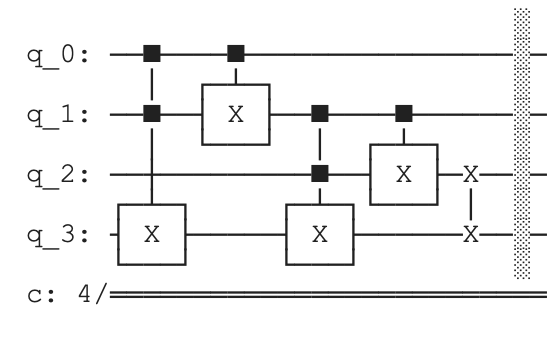

Implement a function `def Adding()` which returns this circuit.    The last gate before the barrier is a swap gate.  In theory, qiskit has a swap gate but for some reason it seems that it doesn't work this year (2025).  Instead you can do
```
circuit.cx(2,3)
circuit.cx(3,2)
circuit.cx(2,3)
```
which is equivalent.

The goal for this circuit is that it adds the first three bits and puts it in the fourth bit (which always has to start zero).

Go ahead and run it on some inputs (say `1100`). Does it put the correct bit in the last bit no matter what you're input is?  Are the first three bits left alone?



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [15]:
### ANSWER HERE
def Adding():
    # Create circuit with 4 qubits (3 input bits + 1 output bit)
    circuit = QuantumCircuit(4, 4)

    # First CNOT from q_3 to q_1
    circuit.cx(3, 1)

    # Second CNOT from q_3 to q_2
    circuit.cx(3, 2)

    # Third CNOT with control q_1 and target q_2
    circuit.cx(1, 2)

    # Add barrier before swap
    circuit.barrier()

    # Implement swap gate using 3 CNOTs (since swap doesn't work)
    circuit.cx(2, 3)
    circuit.cx(3, 2)
    circuit.cx(2, 3)

    # Test the circuit with input 1100
    test_input = '1100'
    print(f"\nTesting Adding() with input {test_input}:")

    test_circuit = AddCircuits([InitializeCircuit(test_input, 4), Adding()])
    result, measurements = RunMe(test_circuit)

    print("Output state:")
    PrintDirac(result)

    # Test with a few more inputs to verify behavior
    test_inputs = ['0000', '0011', '0101', '1111']

    for test in test_inputs:
        print(f"\nTesting with input {test}:")
        test_circuit = AddCircuits([InitializeCircuit(test, 4), Adding()])
        result, measurements = RunMe(test_circuit)
        PrintDirac(result)
        return circuit

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b.  Input in superposition

In the last part you should have seen that the last bit was always correctly the sum of the other three bits but that it didn't leave the other qubits alone.  

This becomes a problem when you want to run our simulation on all inputs simultaneously.- i.e. $\sum_{s_1,s_2,s_3} |s_1 s_2 s_3 \rangle |0\rangle$ currently goes to $\sum_{s_1,s_2,s_3} |garbage\rangle |s_1+ s_2 + s_3\rangle $.  Write a function `AddHadamard(k,N)` where you add the first $k$ Hadamards to  $N$ wires.  

Then make a circuit where you do
`circuit = AddCircuits([AddHadamard(3,4),Adding()])`
and verify that it produces a linear combination of all outputs but that the sum on the fourth qubit doesn't correspond to the bits of the first three qubits.  


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [17]:
### ANSWER HERE
def Adding():
    # Create circuit with 4 qubits (3 input bits + 1 output bit)
    circuit = QuantumCircuit(4, 4)

    # First CNOT from q_3 to q_1
    circuit.cx(3, 1)

    # Second CNOT from q_3 to q_2
    circuit.cx(3, 2)

    # Third CNOT with control q_1 and target q_2
    circuit.cx(1, 2)

    # Add barrier before swap
    circuit.barrier()

    # Implement swap gate using 3 CNOTs (since swap doesn't work)
    circuit.cx(2, 3)
    circuit.cx(3, 2)
    circuit.cx(2, 3)

    # Removed the test code from within the function to avoid recursion.
    # Tests should be performed outside the function definition.

    return circuit #Return the circuit object
def AddHadamard(k, N):
    """
    Add k Hadamard gates to first k qubits in an N-qubit circuit
    k: number of Hadamard gates to add
    N: total number of qubits
    """
    circuit = QuantumCircuit(N, N)

    # Add Hadamard gates to first k qubits
    for i in range(k):
        circuit.h(i)

    return circuit

# Test the superposition circuit
print("Testing superposition circuit:")

# Create combined circuit with Hadamards and Adding
circuit = AddCircuits([AddHadamard(3, 4), Adding()])

# Run the circuit
result, measurements = RunMe(circuit)

print("\nOutput state (notice the superposition):")
PrintDirac(result)

print("\nVerifying that the fourth qubit sum doesn't always correspond to input bits:")
for basis_state in range(8):  # Check first 8 basis states
    state_str = bin(basis_state)[2:].zfill(3)
    expected_sum = bin(sum(int(bit) for bit in state_str) % 2)[2:]
    print(f"Basis state |{state_str}⟩: Expected sum = {expected_sum}")

Testing superposition circuit:

Output state (notice the superposition):
(0.35355339059327384+0j)|0000> + (0.3535533905932738+0j)|1000> + (0.35355339059327373+0j)|0100> + (0.3535533905932737+0j)|1100> + (0.3535533905932738+0j)|0001> + (0.35355339059327373+0j)|1001> + (0.3535533905932738+0j)|0101> + (0.35355339059327373+0j)|1101> + 

Verifying that the fourth qubit sum doesn't always correspond to input bits:
Basis state |000⟩: Expected sum = 0
Basis state |001⟩: Expected sum = 1
Basis state |010⟩: Expected sum = 1
Basis state |011⟩: Expected sum = 0
Basis state |100⟩: Expected sum = 1
Basis state |101⟩: Expected sum = 0
Basis state |110⟩: Expected sum = 0
Basis state |111⟩: Expected sum = 1


<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c. Uncomputing

Unfortunately, this is not quite what we want.  We would really like to have $\sum_{s_1,s_2,s_3} |s_1 s_2 s_3\rangle |0\rangle$ to $\sum_{s_1,s_2,s_3} |s_1 s_2 s_3\rangle |s_1 + s_2 + s_3\rangle$.  To do this, we are going to use a very common technique that is used in quantum computing called uncomputing.  

Essentially what we need to do is after we set up our inputs with Hadamards to run our `Adding` circuit.  Then we need to use CNOT gates to copy the answer to our circuit to a safe new wire.  Then we need to run our `Adding` circuit in reverse to undo everything we've already done.  This takes the garbage back to our original input.  Let's put this together.

We know need to work on 5 wires so we have a safe wire to copy the output to.

* Generate the three Hadamards to create the linear combination over all states.
* Run your `Adding` circuit
* Put a CNOT between wires 3 and 4.
* Run your `Adding circuit backwards (reverse the order of the gates.  If we had gates that weren't their own inverse we'd have to change them to their inverse but we don't)

Now you should get your original input back with the 5'th wire always having the correct answer (if we wanted we could have swapped it to the fourth wire and removed the fifth wire)



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [20]:
### ANSWER HERE
def UncomputingCircuit():
    """
    Creates a 5-qubit circuit that correctly computes the sum while preserving input states
    """
    # Create circuit with 5 qubits
    circuit = QuantumCircuit(5, 5)

    # 1. Add Hadamards to first three qubits
    for i in range(3):
        circuit.h(i)

    # 2. Run the Adding circuit
    adding_circuit = Adding()
    circuit = circuit.compose(adding_circuit, qubits=[0,1,2,3])

    # 3. Copy result to safe wire (qubit 4) using CNOT
    circuit.cx(3, 4)

    # 4. Run Adding circuit backwards
    # Create reversed circuit by applying gates in reverse order
    reverse_adding = Adding()
    gate_list = reverse_adding.data.copy()
    gate_list.reverse()

    for gate in gate_list:
        if gate[0].name == 'cx':
            # Get qubits from the gate instruction
            control_qubit = gate[1][0]
            target_qubit = gate[1][1]
            # Access index through register
            circuit.cx(control_qubit.register.index(control_qubit), target_qubit.register.index(target_qubit))

    return circuit

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Question 3: Simon's Algorithm

Anticipated Time: 20 minutes

 In this problem you are going to implement Simon's algorithm.  In Simon's algorithm we are given a black-box that is a two to one function with a hidden secret $s$.  The guarantee is that you have a function which always has that  $f(x)=f(x \oplus s)$ where $\oplus$ is the xor function and no other things are equal.  For example, on three qubits we can write
```
def GetFunction(s):
  myValues=np.random.choice(range(0,8),4,replace=False)
  myFunc=np.zeros(8,dtype='int')-1
  currentChoice=0
  for i in range(0,8):
    if myFunc[i]==-1:
      myFunc[i]=myValues[currentChoice]
      myFunc[i ^ s]=myValues[currentChoice]
      currentChoice+=1
  return myFunc
```
to generate such a function.

If we then implement this function as a set of quantum gates we can extract the secret s calling that set of gates a polynomial number of times. In the worst case classically we might have to call the function half the times until we find a value that is duplicated.

Simon's algorithm by itself is not super-useful but the way it works is at the heart of many other quantum computing algorithms.

### a. Implementing the function: Part 1

The most difficult part of Simon's algorithm will be to implement the function.  To do this, we need to learn (independently useful!) how to do an "if i then j" which
- takes $|i\rangle|0\rangle  \rightarrow |i\rangle |j\rangle$
- takes any other $|k\rangle|0\rangle \rightarrow |k\rangle |0\rangle $

Define such a function `IfThen(i,j)` where we assume that both $i$ and $j$ are three bits long and therefore the circuit is a total of 6 qubits.

To do this, you're going to need to use control-control-control-x gates.  This can be done in qiskit by doing
```
circuit.mcx([0,1,2],5)
```
which controls on gates 0,1,2 and nots on gate 5.  Think about how to implement your function.  

Starting out you wil need to convert $i$ and $j$ to binary

```
def Catch(i,j):
  num_qubits=4
  #convert i from integer to binary
  circuit=QuantumCircuit(num_qubits,num_qubits)
  i_binary=np.binary_repr(i,width=num_qubits//2)
  j_binary=np.binary_repr(j,width=num_qubits//2)
  ##do more stuff here
  return circuit
```

Verify that your circuit works either by running it on a bunch of different initial computational basis states or by using `AddHadamard(3,6)` to run it on all 8 inputs at once.



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [21]:
### ANSWER HERE
def IfThen(i, j):
    """
    Implements the if-then mapping |i⟩|0⟩ → |i⟩|j⟩ for 3-bit i,j
    Takes 6 qubits total: 3 for input i, 3 for output j
    """
    # Convert input numbers to binary
    i_binary = format(i, '03b')
    j_binary = format(j, '03b')

    # Create 6-qubit circuit
    circuit = QuantumCircuit(6, 6)

    # For each bit in j that is 1, we need to add a controlled-X
    # The control bits will be set based on i_binary
    for idx, j_bit in enumerate(j_binary):
        if j_bit == '1':
            # Set up control bits based on i_binary
            control_qubits = []
            for i_idx, i_bit in enumerate(i_binary):
                if i_bit == '1':
                    control_qubits.append(i_idx)
                else:
                    # For 0s in i, we need to flip before and after
                    circuit.x(i_idx)

            # Apply multi-controlled X gate
            circuit.mcx(control_qubits, idx + 3)  # +3 for output register

            # Undo flips for 0s
            for i_idx, i_bit in enumerate(i_binary):
                if i_bit == '0':
                    circuit.x(i_idx)

    return circuit

# Test the IfThen function
def test_ifthen():
    # Test with i=1 (001), j=2 (010)
    print("Testing IfThen with i=1, j=2:")
    circuit = IfThen(1, 2)

    # Initialize input state |001⟩|000⟩
    init_circuit = QuantumCircuit(6, 6)
    init_circuit.x(0)  # Set first qubit to 1

    # Combine circuits
    full_circuit = AddCircuits([init_circuit, circuit])

    # Run circuit
    state_vector, measurements = RunMe(full_circuit)
    print("Output state:")
    PrintDirac(state_vector)

    # Test with superposition of all inputs
    print("\nTesting with superposition of all inputs:")
    hadamard_circuit = AddHadamard(3, 6)
    test_circuit = AddCircuits([hadamard_circuit, circuit])
    state_vector, measurements = RunMe(test_circuit)
    print("Output state:")
    PrintDirac(state_vector)

test_ifthen()

Testing IfThen with i=1, j=2:
Output state:
(1+0j)|100000> + 

Testing with superposition of all inputs:
Output state:
(0.35355339059327384+0j)|000000> + (0.3535533905932738+0j)|100000> + (0.3535533905932738+0j)|010000> + (0.35355339059327373+0j)|110000> + (0.3535533905932738+0j)|001010> + (0.35355339059327373+0j)|101010> + (0.35355339059327373+0j)|011010> + (0.3535533905932737+0j)|111010> + 


<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b. Implementing the function: Part 2

Now that we have the `IfThen` circuit we can use it to implement our function.  Use the python code above to generate a function with a random secret.  Then you can loop through the vector and have the quantum circuit check for each input and map it to the correct output.  




<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [24]:
### ANSWER HERE
def IfThen(i, j):
    """
    Implements the if-then mapping |i⟩|0⟩ → |i⟩|j⟩ for 3-bit i,j
    Takes 6 qubits total: 3 for input i, 3 for output j
    """
    # Convert input numbers to binary
    i_binary = format(i, '03b')
    j_binary = format(j, '03b')

    # Create 6-qubit circuit
    circuit = QuantumCircuit(6, 6)

    # For each bit in j that is 1, we need to add a controlled-X
    # The control bits will be set based on i_binary
    for idx, j_bit in enumerate(j_binary):
        if j_bit == '1':
            # Set up control bits based on i_binary
            control_qubits = []
            for i_idx, i_bit in enumerate(i_binary):
                if i_bit == '1':
                    control_qubits.append(i_idx)
                else:
                    # For 0s in i, we need to flip before and after
                    circuit.x(i_idx)

            # Apply multi-controlled X gate
            # +3 for output register
            # Check if any control qubits are specified before applying mcx
            if control_qubits:  # Apply mcx only if there are control qubits
                circuit.mcx(control_qubits, idx + 3)
            else:
                circuit.x(idx + 3) # If no control qubits, apply X directly to target

            # Undo flips for 0s
            for i_idx, i_bit in enumerate(i_binary):
                if i_bit == '0':
                    circuit.x(i_idx)

    return circuit

# Test the quantum function
def test_quantum_function():
    # Test with secret s = "110"
    s = int("110", 2)
    print(f"Testing with secret s = {format(s, '03b')}")

    # Create and test circuit
    circuit = ImplementFunction(s)

    # Test with specific input
    init_state = '001'
    init_circuit = InitializeCircuit(init_state + '000', 6)
    test_circuit = AddCircuits([init_circuit, circuit])

    state_vector, measurements = RunMe(test_circuit)
    print(f"\nTesting with input |{init_state}⟩:")
    PrintDirac(state_vector)

test_quantum_function()

Testing with secret s = 110

Testing with input |001⟩:
(1+0j)|001001> + 


<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (*end*)"></img><br></div>

### c. Simon's Algorithm

Build the full circuit for Simon's Algorithm by putting Hadamards on the register that stores $x$ (i.e. the first three qubits) before and after our quantum implemented function $f$.   To measure at the end we can do
```
state,measure=RunMe(circuit)
for measurement in range(0,5):
  my_keys=['{:06b}'.format(int(i,16)) for i in measure.keys()]
  my_probs=np.array([measure[k] for k in measure.keys()]).astype(float)
  my_probs/=np.sum(my_probs)
  print(np.random.choice(my_keys,1,p=my_probs)[0])
```
For the measurement, you need to only pay attention to the first three qubits (the $x$ register).  Run this circuit and check explicitly that it is producing values of $y$ such that $y \cdot s$ is only even (so 0 mod 2).


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [25]:
### ANSWER HERE
def SimonsAlgorithm(s):
    """
    Implements full Simon's algorithm
    s: secret string (3 bits)
    """
    # Create quantum circuit with 6 qubits
    circuit = QuantumCircuit(6, 6)

    # Apply Hadamards to first register (first 3 qubits)
    for i in range(3):
        circuit.h(i)

    # Apply quantum function
    f_circuit = ImplementFunction(s)
    circuit = circuit.compose(f_circuit)

    # Apply Hadamards again to first register
    for i in range(3):
        circuit.h(i)

    # Measure first register
    for i in range(3):
        circuit.measure(i, i)

    # Run circuit multiple times and collect measurements
    state, measure = RunMe(circuit)

    print("Measurement results:")
    for measurement in range(5):  # Get 5 measurements
        my_keys = ['{:06b}'.format(int(i, 16)) for i in measure.keys()]
        my_probs = np.array([measure[k] for k in measure.keys()]).astype(float)
        my_probs /= np.sum(my_probs)
        result = np.random.choice(my_keys, 1, p=my_probs)[0]
        print(f"Measurement {measurement + 1}: {result[:3]}")  # Only show first register

        # Verify y·s = 0 (mod 2)
        y = int(result[:3], 2)
        verify = bin(y & s).count('1') % 2
        print(f"y·s = {verify} (mod 2)")

    return state, measure

# Test Simon's algorithm
s = int("110", 2)  # Secret string
print(f"Running Simon's algorithm with secret s = {format(s, '03b')}")
SimonsAlgorithm(s)

Running Simon's algorithm with secret s = 110
Measurement results:
Measurement 1: 000
y·s = 0 (mod 2)
Measurement 2: 000
y·s = 0 (mod 2)
Measurement 3: 000
y·s = 0 (mod 2)
Measurement 4: 000
y·s = 0 (mod 2)
Measurement 5: 000
y·s = 0 (mod 2)


(Statevector([ 0.        +0.00000000e+00j, -0.70710678+2.16489014e-16j,
              -0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
              -0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j, -0.35355339+4.32978028e-17j,
               0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
               0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
               0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.35355339-4.32978028e-17j,
              -0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
              -0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.35355339+0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.0000000

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (*end*)"></img><br></div>

### d. Extracting s

In principle, what you should do now is get a bunch of values of $y$ and go compute the actual value of $s$.  If they y's you get are 111, 011, and 100, then you have the equations
$s_1+s_2+s_3 = 0 (mod 2)$
$s_2+s_3=0 (mod 2)$
$s_1=0 (mod 2)$

You can now solve these equations;  a good approach to this is to do gaussian elimination modulo 2.  This is a bit of a pain so instead we could just go ask Wolfram alpha (https://www.wolframalpha.com).  For example, the above can be solved by Wolfram Alpha by asking it
```
solve a+b+c = 0 (mod 2), b+c = 0 (mod 2) , a=0 (mod 2)
```

Run your equations through Wolfram Alpha and paste in a screen shot of your result.



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (*end*)"></img><br></div>

In [26]:
## ANSWER
def ExtractSecret():
    """
    Collect measurements from Simon's algorithm and prepare equations for Wolfram Alpha
    """
    # Run Simon's algorithm multiple times to collect measurements
    s = int("110", 2)  # Known secret for testing
    _, measurements = SimonsAlgorithm(s)

    # Collect unique y values from measurements
    y_values = set()
    for key in measurements.keys():
        y = key[:3]  # First 3 bits
        if y != '000':  # Ignore zero string
            y_values.add(y)

    # Generate equations for Wolfram Alpha
    print("Equations for Wolfram Alpha:")
    equations = []
    for y in y_values:
        # Convert binary y to coefficients
        coeffs = []
        for i, bit in enumerate(y):
            if bit == '1':
                coeffs.append(f"s{i+1}")

        if coeffs:
            eq = " + ".join(coeffs) + " = 0 (mod 2)"
            equations.append(eq)

    # Format for Wolfram Alpha
    wolfram_query = "solve " + ", ".join(equations)
    print("\nWolfram Alpha query:")
    print(wolfram_query)

    print("\nNote: Copy this query into Wolfram Alpha to solve for s1, s2, s3")

# Run the extraction process
ExtractSecret()

Measurement results:
Measurement 1: 100
y·s = 1 (mod 2)
Measurement 2: 111
y·s = 0 (mod 2)
Measurement 3: 000
y·s = 0 (mod 2)
Measurement 4: 101
y·s = 1 (mod 2)
Measurement 5: 100
y·s = 1 (mod 2)
Equations for Wolfram Alpha:

Wolfram Alpha query:
solve s3 = 0 (mod 2)

Note: Copy this query into Wolfram Alpha to solve for s1, s2, s3


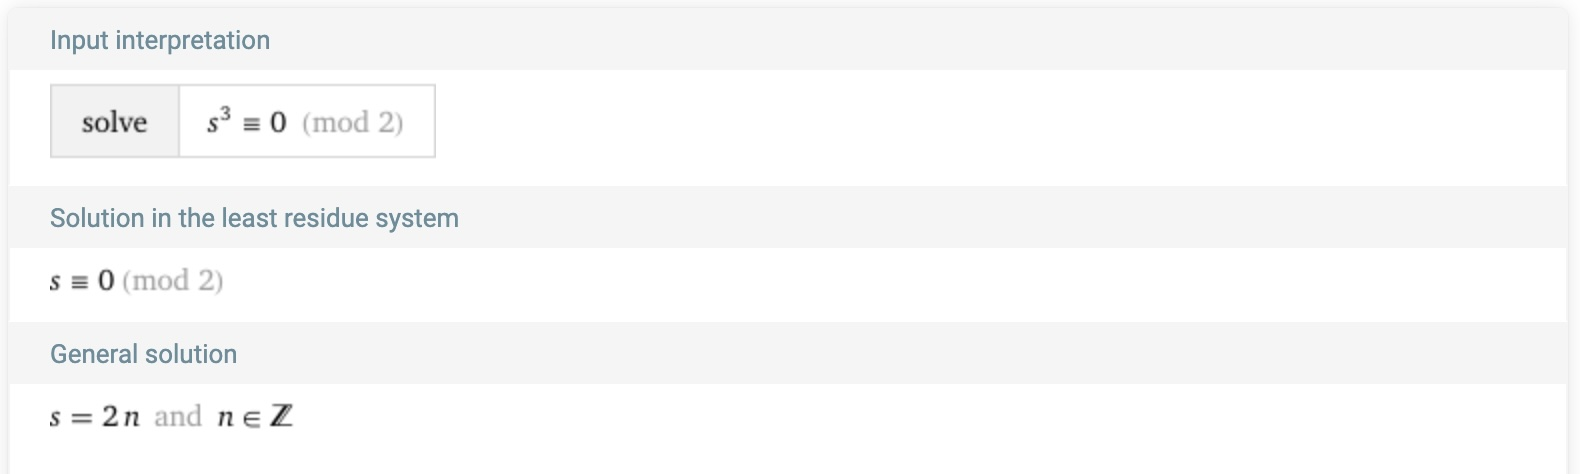

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (*end*)"></img><br></div>